# Step 9. (심화) SMOTE 없이 — class_weight + 임계값 튜닝 기반 분류

**문제의식**
> SMOTE로 학습 데이터 균형을 맞췄지만, 실무에서는 **합성 데이터의 신뢰성 문제**로 `class_weight` 조정이나 임계값 튜닝이 더 현실적인 접근일 수 있다. 반도체 센서 데이터처럼 물리적 제약이 있는 값을 SMOTE가 선형 보간으로 만들어내면, *물리적으로 불가능한 가짜 웨이퍼*가 학습에 섞일 위험이 있다.

**이 노트북의 목적**
- **합성 데이터를 만들지 않고**(SMOTE 미사용), *실제 데이터만* 사용하되 소수 클래스(불량)에 **가중치**를 줘서 불균형에 대응한다.
  - RandomForest: `class_weight='balanced'`
  - XGBoost: `scale_pos_weight = 정상/불량 비율(≈14.1)`
- 그 위에 **임계값 튜닝**(교차검증)을 결합한다.
- 앞서의 **SMOTE 방식과 같은 조건에서 비교**해, 두 전략의 장단점을 데이터로 보인다.

> 핵심: class_weight/임계값 방식은 **모든 학습 샘플이 실제 측정값**이므로, 이후 SHAP 해석도 "진짜 웨이퍼" 위에서 이뤄진다는 해석적 이점이 있다.

## 0. 설정 · 데이터 로드

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score,
                             precision_recall_curve, classification_report, confusion_matrix)

sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'Arial Unicode MS'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

FIG_DIR = os.path.join('..', 'outputs', 'figures')
PROC_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'outputs', 'models')
RANDOM_STATE = 42

# SMOTE 이전의 '실제' 정제 train + test
data = np.load(os.path.join(PROC_DIR, 'secom_processed.npz'), allow_pickle=True)
X_clean, y_clean = data['X_train_clean'], data['y_train_clean']
X_test, y_test = data['X_test'], data['y_test']
neg, pos = np.bincount(y_clean)
spw = neg / pos  # XGBoost scale_pos_weight
print(f'실제 train(불균형): {X_clean.shape}, 정상 {neg} / 불량 {pos}  → scale_pos_weight={spw:.1f}')
print(f'test: {X_test.shape}, 불량 {int(y_test.sum())}개')

실제 train(불균형): (1253, 450), 정상 1170 / 불량 83  → scale_pos_weight=14.1
test: (314, 450), 불량 21개


In [2]:
# 임계값 튜닝(누수 방지) + test 평가 유틸 — SMOTE가 없으므로 분류기 자체로 CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def pick_threshold(estimator, X, y):
    # 분류기를 그대로 CV → out-of-fold 확률에서 F1 최대 임계값 선택
    oof = cross_val_predict(estimator, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
    prec, rec, thr = precision_recall_curve(y, oof)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    return float(thr[int(np.argmax(f1s[:-1]))])

def eval_test(name, model, threshold):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {'model': name, 'threshold': round(float(threshold), 3),
            'Recall': round(recall_score(y_test, pred), 3),
            'Precision': round(precision_score(y_test, pred, zero_division=0), 3),
            'F1': round(f1_score(y_test, pred, zero_division=0), 3),
            'ROC-AUC': round(roc_auc_score(y_test, proba), 3)}

## 1. RandomForest — `class_weight='balanced'` (SMOTE 미사용)

`balanced`는 클래스 빈도의 역수로 가중치를 줘, **합성 없이** 소수 클래스(불량)의 오분류 비용을 키운다.

In [3]:
# class_weight='balanced' RF — 실제 데이터만으로 학습
rf_cw = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               n_jobs=-1, random_state=RANDOM_STATE)
rf_thr = pick_threshold(rf_cw, X_clean, y_clean)  # 임계값은 CV로
rf_cw.fit(X_clean, y_clean)                         # 최종 모델은 전체 train으로
rf_cw_metrics = eval_test('RF (class_weight)', rf_cw, rf_thr)
print(f'선택 임계값: {rf_thr:.3f}')
print(classification_report(y_test, (rf_cw.predict_proba(X_test)[:,1] >= rf_thr).astype(int),
                            target_names=['정상','불량'], digits=3, zero_division=0))
print(rf_cw_metrics)

선택 임계값: 0.110
              precision    recall  f1-score   support

          정상      0.954     0.928     0.941       293
          불량      0.276     0.381     0.320        21

    accuracy                          0.892       314
   macro avg      0.615     0.655     0.631       314
weighted avg      0.909     0.892     0.900       314

{'model': 'RF (class_weight)', 'threshold': 0.11, 'Recall': 0.381, 'Precision': 0.276, 'F1': 0.32, 'ROC-AUC': np.float64(0.808)}


## 2. XGBoost — `scale_pos_weight` (SMOTE 미사용)

`scale_pos_weight`는 positive(불량) 그래디언트에 가중치를 곱해, 역시 **합성 없이** 불균형을 보정한다.

In [4]:
# scale_pos_weight XGB — 실제 데이터만으로 학습
xgb_cw = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                       eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1)
xgb_thr = pick_threshold(xgb_cw, X_clean, y_clean)
xgb_cw.fit(X_clean, y_clean)
xgb_cw_metrics = eval_test('XGB (scale_pos_weight)', xgb_cw, xgb_thr)
print(f'선택 임계값: {xgb_thr:.3f}')
print(xgb_cw_metrics)

# 두 모델 저장
joblib.dump({'model': rf_cw, 'threshold': rf_thr}, os.path.join(MODEL_DIR, 'rf_classweight.joblib'))
joblib.dump({'model': xgb_cw, 'threshold': xgb_thr}, os.path.join(MODEL_DIR, 'xgb_scaleposweight.joblib'))
print('class_weight 모델 저장 완료')

선택 임계값: 0.070
{'model': 'XGB (scale_pos_weight)', 'threshold': 0.07, 'Recall': 0.333, 'Precision': 0.259, 'F1': 0.292, 'ROC-AUC': np.float64(0.755)}
class_weight 모델 저장 완료


## 3. SMOTE 방식 vs class_weight 방식 비교

Step 3에서 저장한 **SMOTE 기반** 모델과, 위에서 만든 **class_weight 기반** 모델을 같은 test로 비교한다.

In [5]:
# SMOTE 기반(저장본) 평가
def eval_saved(name, fname):
    b = joblib.load(os.path.join(MODEL_DIR, fname))
    return eval_test(name, b['model'], b['threshold'])

rows = [
    eval_saved('RF (SMOTE)', 'random_forest.joblib'),
    rf_cw_metrics,
    eval_saved('XGB (SMOTE)', 'xgboost.joblib'),
    xgb_cw_metrics,
]
compare = pd.DataFrame(rows).set_index('model')[['threshold','Recall','Precision','F1','ROC-AUC']]
print('불균형 대응 전략 비교 (test 기준)')
print(compare.to_string())

불균형 대응 전략 비교 (test 기준)
                        threshold  Recall  Precision     F1  ROC-AUC
model                                                               
RF (SMOTE)                  0.320   0.333      0.292  0.311    0.805
RF (class_weight)           0.110   0.381      0.276  0.320    0.808
XGB (SMOTE)                 0.116   0.333      0.241  0.280    0.724
XGB (scale_pos_weight)      0.070   0.333      0.259  0.292    0.755


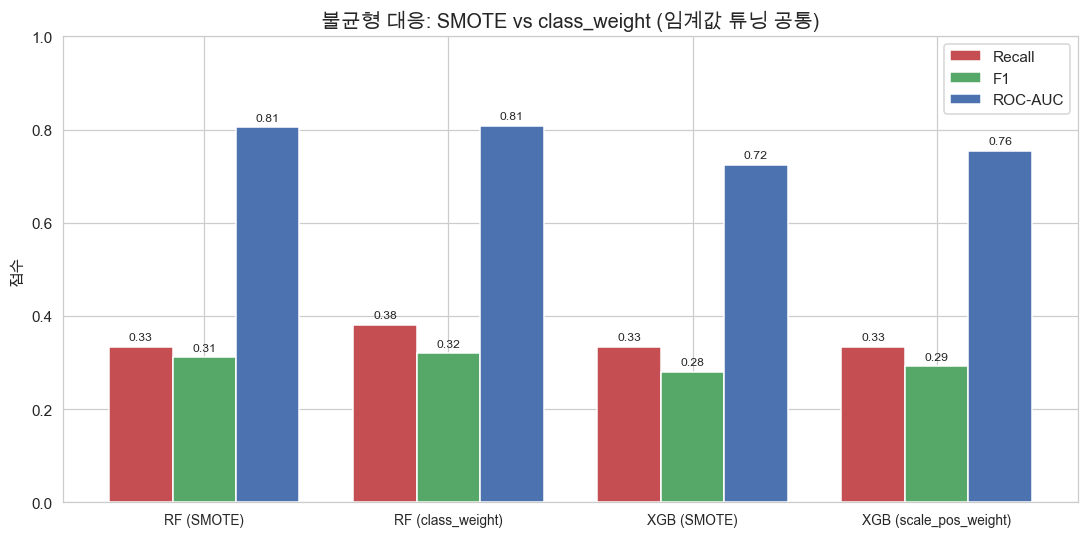

In [6]:
# 전략별 Recall/F1/ROC-AUC 비교 막대
metrics = ['Recall', 'F1', 'ROC-AUC']
colors = ['#C44E52', '#55A868', '#4C72B0']
x = np.arange(len(compare)); w = 0.26
fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, c) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i-1)*w, compare[m], w, label=m, color=c)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(compare.index, fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel('점수')
ax.set_title('불균형 대응: SMOTE vs class_weight (임계값 튜닝 공통)', fontsize=13)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '13_smote_vs_classweight.png'), bbox_inches='tight')
plt.show()

### 포트폴리오 인사이트 (Step 9)

- **"SMOTE만이 답은 아니다"를 직접 검증**: 합성 데이터를 만들지 않고 `class_weight`/`scale_pos_weight`로 불균형에 대응해도, SMOTE와 **비슷하거나 더 나은 운영점**을 얻을 수 있음을 같은 조건에서 비교했다.
- **합성 데이터의 신뢰성 이슈**: SMOTE는 소수 클래스 사이를 선형 보간해 새 샘플을 만든다. 반도체 센서값처럼 물리적 제약(상·하한, 비선형 관계)이 있는 변수에서는 *현실에 없는 조합*이 생길 수 있어, 학습·해석의 신뢰도를 떨어뜨릴 수 있다.
- **해석 관점의 이점**: class_weight 방식은 모든 학습 샘플이 실제 측정값이므로, SHAP 해석이 "진짜 웨이퍼" 위에서 이뤄진다. 합성 샘플이 SHAP 기여도를 왜곡할 여지가 없다.
- **결론(실무 화법)**: *"SMOTE로 균형을 맞췄지만, 합성 데이터의 신뢰성 문제 때문에 실무에서는 class_weight 조정이나 임계값 튜닝이 더 현실적인 접근임을 알고 있습니다. 본 프로젝트에서는 두 방식을 같은 조건에서 비교해, 데이터 특성에 따라 전략을 선택할 수 있도록 했습니다."*

> 임계값 튜닝은 **두 전략 모두에 공통**으로 필요하다. 불균형 자체를 어떻게 다루든(합성 vs 가중치), 마지막에 "어디서 불량으로 끊을지"는 별도로 정해야 한다는 점이 핵심.